In [1]:
%matplotlib widget

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from g4beam import *
from scan import *
from scipy.optimize import differential_evolution
from matplotlib.cm import viridis
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import re
import sys
from pathlib import Path
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
import os
from tabulate import tabulate
import tempfile
import glob
import json
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

### Inci's Preliminary Dispersion Calculation Code

In [5]:
# If particles_after isn't updated with Z = 0.
def convertZ(input_file, output_file):
    event_id_counter = 1
    with open(input_file, "r") as infile, open(output_file, "w") as outfile:
        for line in infile:
            # Skip header lines (those starting with #)
            if line.strip().startswith("#"):
                outfile.write(line)
                continue

            # Split the line into columns
            parts = line.strip().split()
            if len(parts) >= 12:
                parts[2] = "0"  # Set the 3rd column (z) to 0
                # Replace event ID (assuming it's the 9th column, zero-based index 8)
                # Adjust if your event ID is in a different column
                parts[8] = str(event_id_counter)
                event_id_counter += 1
                new_line = " ".join(parts)
                outfile.write(new_line + "\n")
            else:
                # Handle lines that don't match expected format
                outfile.write(line)
    print(f"Updated file saved as '{output_file}'")
    os.remove(input_file)
    return None
convertZ("particles_afterupt.txt", "particles_after.txt")

FileNotFoundError: [Errno 2] No such file or directory: 'particles_afterupt.txt'

In [6]:
# Make Sure g4bl is here
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


In [7]:
# Load data POST WEDGE as a Dataframe so that you can use Daniel Fu's functions
filename = "out_1760039204_1614938.txt"

# Skip the first two header lines that start with '#'
with open(filename) as f:
    # Read until the line containing column names
    for line in f:
        if line.startswith("#x "):
            columns = line.strip().lstrip("#").split()
            break

# Now load the data into a DataFrame
df = pd.read_csv(filename, comment="#", sep='\s+', names=columns)

x_params, y_params, z_emit = calc_all_params(df) # _params are tuples of the form (emittance, beta, gamma, alpha, D, D')
D_dict = {"D_x": x_params[4], "D'_x": x_params[5], "D_y": y_params[4], "D'_y": y_params[5]}
print(D_dict)
cost = D_dict["D_x"]**2 + D_dict["D'_x"]**2 + D_dict["D_y"]**2 + D_dict["D'_y"]**2 
print(cost)
print(r"Epsilon_z: "+str(z_emit))

{'D_x': np.float64(0.015274752174883286), "D'_x": np.float64(-0.16276468456961618), 'D_y': np.float64(-0.0003564703042096456), "D'_y": np.float64(-0.01884340044268174)}
0.027080861408371796
Epsilon_z: 7.5011508670475155


<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1209/583144422.py:13: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filename, comment="#", sep='\s+', names=columns)


In [8]:
# Replace with your beam file
filename = "out_1760039204_1614938.txt"

# Load data assuming BLTrackFile columns: x y z px py pz t particleID ...
# Adjust columns if your file is different
data = np.loadtxt(filename, comments="#")

# Extract px, py, pz
px = data[:, 3]
py = data[:, 4]
pz = data[:, 5]

# Compute average momentum components
px_ref = np.mean(px)
py_ref = np.mean(py)
pz_ref = np.mean(pz)

# Compute average total momentum magnitude
p_ref = np.sqrt(px_ref**2 + py_ref**2 + pz_ref**2)

print(f"Reference particle momentum components: px={px_ref:.6f}, py={py_ref:.6f}, pz={pz_ref:.6f}")
print(f"Reference particle total momentum: p = {p_ref:.6f}")

Reference particle momentum components: px=-0.204087, py=-0.052419, pz=88.961592
Reference particle total momentum: p = 88.961842


In [9]:
desired_p = np.array([-0.204087, -0.204087, 88.961842])  # px, py, pz in MeV/c

data = np.loadtxt("out_1760039204_1614938.txt")
momenta = data[:, 3:6]  # px, py, pz

# Find the particle index closest to desired momentum
dist = np.linalg.norm(momenta - desired_p, axis=1)
ref_index = np.argmin(dist)

print("Use this index in referenceParticle:", ref_index)


Use this index in referenceParticle: 4072


In [10]:
import re
def parse_best_result(text):
    # Regex: captures variable name and numeric value (supports +/-, decimals, exponents)
    pattern = r"([A-Za-z0-9_]+)\s*=\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)"
    matches = re.findall(pattern, text)

    # Convert to dictionary
    result_dict = {k: float(v) for k, v in matches}

    # Optional: turn into NumPy array (just the values)
    keys = list(result_dict.keys())
    values = np.array([result_dict[k] for k in keys])

    # Print them as a Python-style array
    print(", ".join(str(v) for v in values[:-1]))

    return result_dict, keys, values
text = input("Paste the best result from optimization")
result_dict, keys, xvec = parse_best_result(text)

In [18]:
# ---------------- USER CONFIG ----------------
G4BEAMLINE_CMD = "g4bl"
TEMPLATE_FILE = "G4_FinalCooling_wdc_Template.g4bl"
OUTPUT_DIR = "runs"
VD_FILENAME = "vd_B1_end_achromat.txt"   # virtual detector writes this file (ascii)
N_PARTICLES = 5000             # increase for lower noise
G4BLFILE = f"G4_FinalCooling_wdc_Template_run.g4bl"
G4BLOUTPUT =f"/home/incik/Cooling_4D/AchromatOneByOne/{VD_FILENAME}"
E0 = 1e4                       # beam energy (GeV) - for a muon collider

# Let's first take in the parameters that the wedge has
import re
import math
import sys
from pathlib import Path

def read_g4bl_params(filename):
    """
    Reads 'param' definitions from a .g4bl file and returns a dict of parameter names and values.
    """
    params = {}
    pattern = re.compile(r"param\s+(?:-unset\s+)?(\w+)=([^\s#]+)")
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("param"):
                continue
            m = pattern.search(line)
            if m:
                key, val = m.groups()
                try:
                    params[key] = float(eval(val, {"__builtins__": None, "pi": math.pi}))
                except Exception:
                    params[key] = val  # keep as string if not numeric
    return params


def compute_wedge_geometry(params):
    """
    Given parameters like absLEN3, abshgt, abswidth, abshalfangle3, compute geometry info.
    """
    W = params.get("absLEN3")
    H = params.get("abshgt")
    L = params.get("abswidth")
    half_angle_deg = params.get("abshalfangle3")
    offset = params.get("absoffset3", 0)

    if L and half_angle_deg:
        half_angle_rad = math.radians(half_angle_deg)
        thickness_tip = L / (2 * math.tan(half_angle_rad))
    else:
        thickness_tip = None

    return {
        "Length_Wedge": L,
        "Height_Base": H,
        "Width_Base": W,
        "Half-angle": half_angle_deg,
        "Tip Thickness": thickness_tip,
        "Offset": offset
    }


if len(sys.argv) < 2:
    print("Usage: python read_wedge_params.py <file.g4bl>")
    sys.exit(1)

file_path = "G4_FinalCooling_wdc_Template.g4bl"
params = read_g4bl_params(file_path)
geom = compute_wedge_geometry(params)

print("Parameters found:")
for k, v in params.items():
    print(f"  {k:15s} = {v}")

print("Derived geometry:")
for k, v in geom.items():
    print(f"  {k:20s}: {v}")

Parameters found:
  zbegin          = 0.0
  steppingFormat  = N,GLOBAL,CL,STEP,VOL,PROCESS,P,KE,POLAR,B
  fieldVoxels     = 400,400,400
  maxStep         = 0.5
  minRangeCut     = 1.0
  nparticles      = 1000.0
  beamfile        = particles_before.txt
  pi              = 3.141592654
  degrad          = $pi/180
  abshgt          = 10.0
  abswidth        = 100.0
  absLEN3         = 18.0
  abshalfangle3   = 45.0
  absoffset3      = 3.2
  wedge_z         = 0.5*$absLEN3
  VDRad           = 60.0
  wedgeAxis       = 0.0
  noWedge         = 0.0
Derived geometry:
  Length_Wedge        : 100.0
  Height_Base         : 10.0
  Width_Base          : 18.0
  Half-angle          : 45.0
  Tip Thickness       : 50.00000000000001
  Offset              : 3.2


In [ ]:
# {B1_field}, {B1_width}, {B1_height}, {B1_length}, {B1_z}, {Q1_gradient}, {Q1_length}, {radius_q}
# {B2_field}, {B2_width}, {B2_height}, {B2_length}
# {Drift1_width}, {Drift1_height}, {Drift1_length}, 
# {Drift2_width}, {Drift2_height}, {Drift2_length}

var_names = ["N_PARTICLES", "B1_field", "B1_width", "B1_height", "B1_length", "B1_z",
            "Q1_gradient", "Q1_length", "radius_q", "B2_field", "B2_width", "B2_height", "B2_length",
            "Drift1_width", "Drift1_height", "Drift1_length", "Drift2_width", "Drift2_height", "Drift2_length", "VD_FILENAME"]
    
xvec = np.array([int(N_PARTICLES), -0.133, 74.7401, geom["Length_Wedge"], 267.6652, 177.7786, -43.4531, 73.1234, geom["Length_Wedge"], -0.0126, 167.5582, 
                144.8055, 53.6328, 120.1356, geom["Length_Wedge"], 463.8105, 102.022, geom["Length_Wedge"], 316.7456, VD_FILENAME])

calcparams = {name: val for name, val in zip(var_names, xvec)}

GAP = 0.1  # in mm (can be up to 1.0 safely)
B1_z_val = float(calcparams["B1_z"])
L_B1 = float(calcparams["B1_length"])
L_D1 = float(calcparams["Drift1_length"])
L_Q1 = float(calcparams["Q1_length"])
L_D2 = float(calcparams["Drift2_length"])
L_B2 = float(calcparams["B2_length"])

Drift1_z = B1_z_val + (L_B1/2) + (L_D1/2) + GAP
Q1_z     = Drift1_z + (L_D1/2) + (L_Q1/2) + GAP
Drift2_z = Q1_z + (L_Q1/2) + (L_D2/2)+ GAP
B2_z     = Drift2_z + (L_D2/2) + (L_B2/2) + GAP
VD_z     = B2_z + (L_B2/2) + 10.0 + GAP

B1_end = B1_z_val + (L_B1/2)
D1_end = Drift1_z + (L_D1/2)
Q1_end = Q1_z + (L_Q1/2)
D2_end = Drift2_z + (L_D2/2)
B2_end = B2_z + (L_B2/2)

add_params = {"Drift1_z": Drift1_z, "Q1_z": Q1_z, "Drift2_z":Drift2_z, "B2_z": B2_z, "VD_z": VD_z, 
            "B1_end": B1_end, "B2_end": B2_end,  "D1_end": D1_end, "Q1_end": Q1_end,  "D2_end": D2_end}

calcparams.update(add_params)

for k, v in calcparams.items():
    if k == "N_PARTICLES" or k == "VD_FILENAME":
        continue
    else:
        calcparams[k] = float(v)

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [20]:
# Write values to the prepared G4BL template
def write_input_from_template(template_path, out_path, replacements):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

# How to Use?
print(calcparams)
write_input_from_template(TEMPLATE_FILE, G4BLFILE, calcparams)

{'N_PARTICLES': np.str_('5000'), 'B1_field': -0.133, 'B1_width': 74.7401, 'B1_height': 100.0, 'B1_length': 267.6652, 'B1_z': 177.7786, 'Q1_gradient': -43.4531, 'Q1_length': 73.1234, 'radius_q': 100.0, 'B2_field': -0.0126, 'B2_width': 167.5582, 'B2_height': 144.8055, 'B2_length': 53.6328, 'Drift1_width': 120.1356, 'Drift1_height': 100.0, 'Drift1_length': 463.8105, 'Drift2_width': 102.022, 'Drift2_height': 100.0, 'Drift2_length': 316.7456, 'VD_FILENAME': np.str_('vd_B1_end_achromat.txt'), 'Drift1_z': 543.6164500000001, 'Q1_z': 812.1834000000001, 'Drift2_z': 1007.2179000000001, 'B2_z': 1192.5071, 'VD_z': 1229.4234999999999, 'B1_end': 311.61120000000005, 'B2_end': 1219.3235, 'D1_end': 775.5217000000001, 'Q1_end': 848.7451000000001, 'D2_end': 1165.5907000000002}


In [55]:
# Run g4bl and get the Output file
G4BLFILE = f"G4_FinalCooling_wdc_run_40.0_7.g4bl"
G4BLOUTPUT3 = f"vd_B1_end_achromat_40.0_7.txt"
G4BLOUTPUT2 = f"vd_wedge_end_achromat.txt"
G4BLOUTPUT1= f"vd_start_achromat.txt"
if os.path.exists("field_cell.dat"):
    os.remove("field_cell.dat")
result = subprocess.run(["g4bl", G4BLFILE], capture_output=True, text=True, check=True)
print(result)

CompletedProcess(args=['g4bl', 'G4_FinalCooling_wdc_run_40.0_7.g4bl'], returncode=0, stdout="G4BL_DIR=/home/incik/G4beamline-3.08\nG4LEDATA=/home/incik/Geant4Data/G4EMLOW8.0\nG4ENSDFSTATEDATA=/home/incik/Geant4Data/G4ENSDFSTATE2.3\nG4PARTICLEXSDATA=/home/incik/Geant4Data/G4PARTICLEXS4.0\nG4LEVELGAMMADATA=/home/incik/Geant4Data/PhotonEvaporation5.7\nG4RADIOACTIVEDATA=/home/incik/Geant4Data/RadioactiveDecay5.6\nG4beamline Process ID 12246\n\n*************************************************************\n g4beamline version: 3.08                        (Aug 11 2022)\n                      Copyright : Tom Roberts, Muons, Inc.\n                        License : Gnu Public License\n                            WWW : http://g4beamline.muonsinc.com\n\n          ################################\n          !!! G4Backtrace is activated !!!\n          ################################\n\n\n**************************************************************\n Geant4 version Name: geant4-11-00-patch-02 [MT

In [56]:
# Make the results a dataframe and calculate the Courant-Snyder Parameters
df1 = read_trackfile(G4BLOUTPUT1)
x_params2, y_params2, z_emit2 = calc_all_params(df1)
df2 = read_trackfile(G4BLOUTPUT2)
x_params1, y_params1, z_emit1 = calc_all_params(df2)
df3 = read_trackfile(G4BLOUTPUT3)
x_params3, y_params3, z_emit3 = calc_all_params(df3)

In [57]:
x_params1, y_params1, z_emit1
x_params2, y_params2, z_emit2
x_params3, y_params3, z_emit3

((np.float64(0.19226372793368876),
  np.float64(0.11659134133177176),
  np.float64(36.085750241583014),
  np.float64(-1.7908897296119242),
  np.float64(-0.003775799586524168),
  np.float64(-0.254244734473763)),
 (np.float64(0.15904022983848073),
  np.float64(0.20338184000362447),
  np.float64(58.408475382361814),
  np.float64(-3.2983667465991635),
  np.float64(-0.0026674796016744914),
  np.float64(-0.03434204409131273)),
 np.float64(10.072655204060831))

In [58]:
D_dict1 = {"D_x": x_params1[4], "D'_x": x_params1[5], "D_y": y_params1[4], "D'_y": y_params1[5]}
print(D_dict1)
cost1 = D_dict1["D_x"]**2 + D_dict1["D'_x"]**2 + D_dict1["D_y"]**2 + D_dict1["D'_y"]**2 
print(cost1)
print(r"Epsilon_z: "+str(z_emit1))

D_dict2 = {"D_x": x_params2[4], "D'_x": x_params2[5], "D_y": y_params2[4], "D'_y": y_params2[5]}
print(D_dict2)
cost2 = D_dict2["D_x"]**2 + D_dict2["D'_x"]**2 + D_dict2["D_y"]**2 + D_dict2["D'_y"]**2 
print(cost2)
print(r"Epsilon_z: "+str(z_emit2))

D_dict3 = {"D_x": x_params3[4], "D'_x": x_params3[5], "D_y": y_params3[4], "D'_y": y_params3[5]}
print(D_dict3)
cost3 = D_dict3["D_x"]**2 + D_dict3["D'_x"]**2 + D_dict3["D_y"]**2 + D_dict3["D'_y"]**2 
print(cost3)
print(r"Epsilon_z: "+str(z_emit3))

{'D_x': np.float64(0.00452614066723463), "D'_x": np.float64(-0.2131956216392943), 'D_y': np.float64(-0.00013176758676966487), "D'_y": np.float64(-0.014380406017374716)}
0.0456796724754262
Epsilon_z: 9.86934263436145
{'D_x': np.float64(8.005925889122585e-05), "D'_x": np.float64(0.1698199156162371), 'D_y': np.float64(0.004011887046569255), "D'_y": np.float64(-0.23442888942781928)}
0.08381180958542597
Epsilon_z: 1.4557145554339148
{'D_x': np.float64(-0.003775799586524168), "D'_x": np.float64(-0.254244734473763), 'D_y': np.float64(-0.0026674796016744914), "D'_y": np.float64(-0.03434204409131273)}
0.06584113310994687
Epsilon_z: 10.072655204060831


In [59]:
with open(G4BLOUTPUT1) as f:
    N_out1 = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out1)
with open(G4BLOUTPUT2) as f:
    N_out2 = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out2)
with open(G4BLOUTPUT3) as f:
    N_out3 = sum(1 for line in f if not line.startswith("#") and line.strip())
    print(N_out3)


# Compute transmission (%)
trans_percent1 = 100.0 * N_out1 / int(N_PARTICLES)
trans_percent2 = 100.0 * N_out2 / int(N_PARTICLES)
trans_percent3 = 100.0 * N_out2 / int(N_PARTICLES)

print(trans_percent1, trans_percent2, trans_percent3)

1000
964
877
20.0 19.28 19.28


## Varying Some Parameters

In [60]:
# Make Sure g4bl is here
import os
os.environ["PATH"] += os.pathsep + "/home/incik/G4beamline-3.08/bin"
import shutil
print(shutil.which("g4bl"))

/home/incik/G4beamline-3.08/bin/g4bl


In [61]:
# --------------- Calculation Functions -----------------
def read_g4bl_params(filename):
    """
    Reads 'param' definitions from a .g4bl file and returns a dict of parameter names and values.
    """
    params = {}
    pattern = re.compile(r"param\s+(?:-unset\s+)?(\w+)=([^\s#]+)")
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("param"):
                continue
            m = pattern.search(line)
            if m:
                key, val = m.groups()
                try:
                    params[key] = float(eval(val, {"__builtins__": None, "pi": math.pi}))
                except Exception:
                    params[key] = val  # keep as string if not numeric
    return params

# Compute wedge elements
def compute_wedge_geometry(params):
    """
    Given parameters like absLEN3, abshgt, abswidth, abshalfangle3, compute geometry info.
    """
    W = params.get("absLEN3")
    H = params.get("abshgt")
    L = params.get("abswidth")
    half_angle_deg = params.get("abshalfangle3")
    offset = params.get("absoffset3", 0)

    if L and half_angle_deg:
        half_angle_rad = math.radians(half_angle_deg)
        L_centerline = W / math.sin(half_angle_rad)

    return {
        "Length_Wedge": L,
        "Height_Base": H,
        "Width_Base": W,
        "Half-angle": half_angle_deg,
        "Centerline_Coords": L_centerline,
        "Offset": offset
    }

# Calculate all will-be-added parameters in the template
def add_missing_params(calcparams_given):
    GAP = 0.1  # in mm (can be up to 1.0 safely)
    A_GAP = 5 # mm
    L_B1 = float(calcparams_given["B1_length"])
    L_D1 = float(calcparams_given["Drift1_length"])
    L_Q1 = float(calcparams_given["Q1_length"])
    L_D2 = float(calcparams_given["Drift2_length"])
    L_B2 = float(calcparams_given["B2_length"])

    wedge_end = geom["Centerline_Coords"]
    B1_z = geom["Centerline_Coords"] + (L_B1/2) + A_GAP
    Drift1_z = B1_z + (L_B1/2) + (L_D1/2) + GAP
    Q1_z     = Drift1_z + (L_D1/2) + (L_Q1/2) + GAP
    Drift2_z = Q1_z + (L_Q1/2) + (L_D2/2)+ GAP
    B2_z     = Drift2_z + (L_D2/2) + (L_B2/2) + GAP
    VD_z     = B2_z + (L_B2/2) + 10.0 + GAP

    B1_end = B1_z + (L_B1/2)
    D1_end = Drift1_z + (L_D1/2)
    Q1_end = Q1_z + (L_Q1/2)
    D2_end = Drift2_z + (L_D2/2)
    B2_end = B2_z + (L_B2/2)

    add_params = {"wedge_end": wedge_end, "B1_z": B1_z, "Drift1_z": Drift1_z, "Q1_z": Q1_z, "Drift2_z":Drift2_z, "B2_z": B2_z, "VD_z": VD_z, 
            "B1_end": B1_end, "B2_end": B2_end,  "D1_end": D1_end, "Q1_end": Q1_end,  "D2_end": D2_end}

    calcparams_given.update(add_params)
    
    for k, v in calcparams_given.items():
        if k == "N_PARTICLES" or k == "VD_FILENAME" or k == "VD_AFILENAME":
            continue
        else:
            calcparams_given[k] = float(v)
    
    return calcparams_given

# Write values to the prepared G4BL template
def write_input_from_template(template_path, out_path, replacements):
    with open(template_path, 'r') as f:
        txt = f.read()
    try:
        txt = txt.format(**replacements)
    except KeyError as e:
        raise RuntimeError(f"Template substitution failed; missing placeholder: {e}")
    with open(out_path, 'w') as f:
        f.write(txt)

In order to be able to do a sweep with physical values, we'd first like to make an array of permissible dipole width and lengths. This means that we'd like to artificially set a predicted transmission of about 0.95. The idea is as follows:
1) Using the particle distribution after the wedge, we calculate the deviation particles in the distribution will have due to the B field we are sweeping through and make sure we are keeping the widths and lengths such that the deviation $\Delta r = r(1-\text{cos}(\frac{\text{Dipole Length}}{r}))$ where $r = \frac{p_T}{q |\vec{B}|}$ is our Larmor radius.
2) Then using these permissible width,length, strengths, we sweep through them to retrieve the transmission, dispersion etc. information of the particle distribution at the end of the dipole.

In [62]:
# ---------------- USER CONFIG ----------------
G4BEAMLINE_CMD = "g4bl"
TEMPLATE_FILE = "G4_FinalCooling_wdc_Template.g4bl"
OUTPUT_DIR = "runs"
VD_AFILENAME = "vd_wedge_end_achromat"   # virtual detector writes this file (ascii)
VD_FILENAME = "vd_B1_end_achromat" 
N_PARTICLES = 5000             # increase for lower noise
G4BLFILE = f"G4_FinalCooling_wdc_run"
E0 = 1e4                       # beam energy (GeV) - for a muon collider
os.makedirs(OUTPUT_DIR, exist_ok=True)

file_path = "G4_FinalCooling_wdc_Template.g4bl"
params = read_g4bl_params(file_path)
geom = compute_wedge_geometry(params)

print("Parameters found:")
for k, v in params.items():
    print(f"  {k:15s} = {v}")

print("Derived geometry:")
for k, v in geom.items():
    print(f"  {k:20s}: {v}")

Parameters found:
  zbegin          = 0.0
  steppingFormat  = N,GLOBAL,CL,STEP,VOL,PROCESS,P,KE,POLAR,B
  fieldVoxels     = 400,400,400
  maxStep         = 0.5
  minRangeCut     = 1.0
  nparticles      = {N_PARTICLES}
  beamfile        = particles_before.txt
  pi              = 3.141592654
  degrad          = $pi/180
  abshgt          = 10.0
  abswidth        = 100.0
  absLEN3         = 18.0
  abshalfangle3   = 45.0
  absoffset3      = 3.2
  wedge_z         = 0.5*$absLEN3
  VDRad           = 60.0
  wedgeAxis       = 0.0
  noWedge         = 0.0
Derived geometry:
  Length_Wedge        : 100.0
  Height_Base         : 10.0
  Width_Base          : 18.0
  Half-angle          : 45.0
  Centerline_Coords   : 25.455844122715714
  Offset              : 3.2


In [63]:
def check_dipole_clearance(df, B_val, dipole_length_mm, dipole_halfwidth_mm):
    """
    Check which particles clear the dipole aperture based on their Larmor radius
    and deflection geometry.

    Parameters:
      df : pandas.DataFrame with columns ['Px','Py','Pz'] in MeV/c
      B_val : magnetic field (Tesla)
      dipole_length_mm : dipole magnet effective length (mm)
      dipole_halfwidth_mm : half-width of dipole aperture (mm)

    Returns:
      surviving_mask : boolean array, True if particle clears aperture
      r_L_mm : array of Larmor radii (mm)
      delta_r_mm : array of deflections (mm)
    """

    # constants
    e = 1.602176634e-19  # C
    c = 2.99792458e8     # m/s

    # convert MeV/c to SI (kg·m/s)
    mom_perp = np.sqrt(df["Px"]**2 + df["Pz"]**2) * 1e6 * e / c  # B assumed along y

    # Larmor radius [m]
    r_L = mom_perp / (e * np.abs(B_val))

    # convert to mm
    r_L_mm = r_L * 1e3
    s_mm = dipole_length_mm

    # deflection Δr = r * (1 - cos(φ)), φ = s / r
    phi = s_mm / r_L_mm
    delta_r_mm = r_L_mm * (1 - np.cos(phi))

    # check if deflection < half-width
    surviving_mask = delta_r_mm < dipole_halfwidth_mm
    

    return surviving_mask, r_L_mm, delta_r_mm

In [64]:
# Doing this for B1 and B1_length
B1_field_range = np.arange(-3.0, 3.0, 0.2)
B1_length_range = np.linspace(10, 100, 10) # in mm

# Initialize lists
results = []

for L_val in B1_length_range:
    Dip1 = []
    for i, B_val in enumerate(tqdm(B1_field_range, desc=f"L = {L_val:.1f}")):
        if os.path.exists("field_cell.dat"):
            os.remove("field_cell.dat")

        var_names = ["N_PARTICLES", "B1_field", "B1_width", "B1_height", "B1_length",
                    "Q1_gradient", "Q1_length", "radius_q", "B2_field", "B2_width", "B2_height", "B2_length",
                    "Drift1_width", "Drift1_height", "Drift1_length", "Drift2_width", "Drift2_height", "Drift2_length", "VD_FILENAME", "VD_AFILENAME"]
        #74.7401
        xvec = np.array([
            int(N_PARTICLES), B_val, 30.0, geom["Length_Wedge"], L_val,
            -43.4531, 73.1234, geom["Length_Wedge"], -0.0126, 167.5582, 144.8055, 53.6328,
            120.1356, geom["Length_Wedge"], 463.8105, 102.022, geom["Length_Wedge"], 316.7456,
            "vd_B1_end_achromat.txt", f"./runs/newruns/{VD_AFILENAME}_{L_val:.1f}_{i}.txt"
        ])

        calcparams = {name: val for name, val in zip(var_names, xvec)}
        add_missing_params(calcparams)
        
        write_input_from_template(
            TEMPLATE_FILE,
            f"/home/incik/Cooling_4D/AchromatOneByOne/runs/newruns/{G4BLFILE}_{L_val:.1f}_{i}.g4bl",
            calcparams
        )

        subprocess.run(["g4bl", f"/home/incik/Cooling_4D/AchromatOneByOne/runs/newruns/{G4BLFILE}_{L_val:.1f}_{i}.g4bl"], 
                    capture_output=True, text=True, check=True)

        G4BLOUTPUT = f"/home/incik/Cooling_4D/AchromatOneByOne/runs/newruns/{VD_AFILENAME}_{L_val:.1f}_{i}.txt"
        df = read_trackfile(G4BLOUTPUT)
        
        # Skip if radii exceed Larmor-defined aperture
        mask, r_L_mm, delta_r_mm = check_dipole_clearance(df, B_val, L_val, calcparams["B1_width"]/2)
        
        # If less than 95% of particles clear the aperture, skip this configuration
        if np.mean(mask) < 0.95:
            print(f"Skipping B={B_val:.2f}T, L={L_val:.1f}mm: only {np.mean(mask)*100:.1f}% clear.")
            continue
        
        Dip1.append(B_val)
        
    # store all results for this L_val
    results.append({
        "B1_length": L_val,
        "Dip1": Dip1,
    })
    
    print(results)



L = 10.0: 100%|██████████| 30/30 [01:43<00:00,  3.45s/it]


[{'B1_length': np.float64(10.0), 'Dip1': [np.float64(-3.0), np.float64(-2.8), np.float64(-2.5999999999999996), np.float64(-2.3999999999999995), np.float64(-2.1999999999999993), np.float64(-1.9999999999999991), np.float64(-1.799999999999999), np.float64(-1.5999999999999988), np.float64(-1.3999999999999986), np.float64(-1.1999999999999984), np.float64(-0.9999999999999982), np.float64(-0.799999999999998), np.float64(-0.5999999999999979), np.float64(-0.3999999999999977), np.float64(-0.1999999999999975), np.float64(2.6645352591003757e-15), np.float64(0.20000000000000284), np.float64(0.400000000000003), np.float64(0.6000000000000032), np.float64(0.8000000000000034), np.float64(1.0000000000000036), np.float64(1.2000000000000037), np.float64(1.400000000000004), np.float64(1.600000000000004), np.float64(1.8000000000000043), np.float64(2.0000000000000044), np.float64(2.2000000000000046), np.float64(2.400000000000005), np.float64(2.600000000000005), np.float64(2.800000000000005)]}]


L = 20.0: 100%|██████████| 30/30 [01:45<00:00,  3.52s/it]


[{'B1_length': np.float64(10.0), 'Dip1': [np.float64(-3.0), np.float64(-2.8), np.float64(-2.5999999999999996), np.float64(-2.3999999999999995), np.float64(-2.1999999999999993), np.float64(-1.9999999999999991), np.float64(-1.799999999999999), np.float64(-1.5999999999999988), np.float64(-1.3999999999999986), np.float64(-1.1999999999999984), np.float64(-0.9999999999999982), np.float64(-0.799999999999998), np.float64(-0.5999999999999979), np.float64(-0.3999999999999977), np.float64(-0.1999999999999975), np.float64(2.6645352591003757e-15), np.float64(0.20000000000000284), np.float64(0.400000000000003), np.float64(0.6000000000000032), np.float64(0.8000000000000034), np.float64(1.0000000000000036), np.float64(1.2000000000000037), np.float64(1.400000000000004), np.float64(1.600000000000004), np.float64(1.8000000000000043), np.float64(2.0000000000000044), np.float64(2.2000000000000046), np.float64(2.400000000000005), np.float64(2.600000000000005), np.float64(2.800000000000005)]}, {'B1_length': 

L = 30.0: 100%|██████████| 30/30 [01:47<00:00,  3.59s/it]


...

Skipping B=2.40T, L=100.0mm: only 0.1% clear.


L = 100.0:  97%|█████████▋| 29/30 [01:42<00:03,  3.22s/it]

Skipping B=2.60T, L=100.0mm: only 0.2% clear.


L = 100.0: 100%|██████████| 30/30 [01:45<00:00,  3.53s/it]

Skipping B=2.80T, L=100.0mm: only 0.3% clear.
[{'B1_length': np.float64(10.0), 'Dip1': [np.float64(-3.0), np.float64(-2.8), np.float64(-2.5999999999999996), np.float64(-2.3999999999999995), np.float64(-2.1999999999999993), np.float64(-1.9999999999999991), np.float64(-1.799999999999999), np.float64(-1.5999999999999988), np.float64(-1.3999999999999986), np.float64(-1.1999999999999984), np.float64(-0.9999999999999982), np.float64(-0.799999999999998), np.float64(-0.5999999999999979), np.float64(-0.3999999999999977), np.float64(-0.1999999999999975), np.float64(2.6645352591003757e-15), np.float64(0.20000000000000284), np.float64(0.400000000000003), np.float64(0.6000000000000032), np.float64(0.8000000000000034), np.float64(1.0000000000000036), np.float64(1.2000000000000037), np.float64(1.400000000000004), np.float64(1.600000000000004), np.float64(1.8000000000000043), np.float64(2.0000000000000044), np.float64(2.2000000000000046), np.float64(2.400000000000005), np.float64(2.600000000000005), n

In [65]:
"""# Doing this for B1 and B1_length
B1_field_range = np.arange(-3.0, 3.0, 0.2)
B1_length_range = np.linspace(10, 100, 10) # in mm"""

# Initialize lists
sweep_results = []
for lsdict in results:
    
    L_val = lsdict["B1_length"]
    B_array = lsdict["Dip1"]
    
    Dx, Dy, Dxp, Dyp, Dip1, emit_x, emit_y, emit_z, transmission, x, xp, y, yp  = [], [], [], [], [], [], [], [], [], [], [], [], []
    
    for i, B_val in enumerate(tqdm(B_array, desc=f"L = {L_val:.1f}")):
        if os.path.exists("field_cell.dat"):
            os.remove("field_cell.dat")
        var_names = ["N_PARTICLES", "B1_field", "B1_width", "B1_height", "B1_length",
                    "Q1_gradient", "Q1_length", "radius_q", "B2_field", "B2_width", "B2_height", "B2_length",
                    "Drift1_width", "Drift1_height", "Drift1_length", "Drift2_width", "Drift2_height", "Drift2_length", "VD_FILENAME", "VD_AFILENAME"]
        #74.7401
        xvec = np.array([
            int(N_PARTICLES), B_val, 30.0, geom["Length_Wedge"], L_val,
            -43.4531, 73.1234, geom["Length_Wedge"], -0.0126, 167.5582, 144.8055, 53.6328,
            120.1356, geom["Length_Wedge"], 463.8105, 102.022, geom["Length_Wedge"], 316.7456,
            f"./runs/newruns/{VD_FILENAME}_{L_val:.1f}_{i}.txt", "vd_wedge_end_achromat.txt"
        ])

        calcparams = {name: val for name, val in zip(var_names, xvec)}
        add_missing_params(calcparams)
        
        write_input_from_template(
            TEMPLATE_FILE,
            f"/home/incik/Cooling_4D/AchromatOneByOne/runs/newruns/{G4BLFILE}_{L_val:.1f}_{i}.g4bl",
            calcparams
        )

        subprocess.run(["g4bl", f"/home/incik/Cooling_4D/AchromatOneByOne/runs/newruns/{G4BLFILE}_{L_val:.1f}_{i}.g4bl"], 
                    capture_output=True, text=True, check=True)

        G4BLOUTPUT = f"/home/incik/Cooling_4D/AchromatOneByOne/runs/newruns/{VD_FILENAME}_{L_val:.1f}_{i}.txt"
        df = read_trackfile(G4BLOUTPUT)
    
        with open(G4BLOUTPUT) as f:
            N_out = sum(1 for line in f if not line.startswith("#") and line.strip())
            print(N_out)

        # Compute transmission (%)
        trans_percent = 100.0 * N_out / int(N_PARTICLES)
        transmission.append(trans_percent)
        
        # Compute D, D', Emittances vs. Dipole Strength
        x_params, y_params, z_emit = calc_all_params(df)

        Dip1.append(B_val)
        Dx.append(x_params[4])
        Dy.append(y_params[4])
        Dxp.append(x_params[5])
        Dyp.append(y_params[5])
        emit_x.append(x_params[0])
        emit_y.append(y_params[0])
        emit_z.append(z_emit)
    
    # store all results for this L_val
    sweep_results.append({
        "B1_length": L_val,
        "Dip1": Dip1,
        "Dx": Dx, "Dy": Dy, "Dxp": Dxp, "Dyp": Dyp, "xp": xp, "yp": yp, "x": x, "y":y,
        "emit_x": emit_x, "emit_y": emit_y, "emit_z": emit_z, "transmission": transmission
    })

L = 10.0:   3%|▎         | 1/30 [00:03<01:38,  3.41s/it]

4829


L = 10.0:   7%|▋         | 2/30 [00:06<01:35,  3.40s/it]

4829


L = 10.0:  10%|█         | 3/30 [00:10<01:31,  3.38s/it]

...

3492


L = 100.0:  80%|████████  | 4/5 [00:17<00:04,  4.37s/it]

3408


L = 100.0: 100%|██████████| 5/5 [00:21<00:00,  4.33s/it]

3159


In [66]:
def find_first_zero_crossing(x_vals, y_vals):
    """Return the first B where y crosses zero (linear interpolation)."""
    y_vals = np.array(y_vals)
    x_vals = np.array(x_vals)
    
    for i in range(len(y_vals)-1):
        if y_vals[i] * y_vals[i+1] <= 0:  # sign change or exact zero
            x0, x1 = x_vals[i], x_vals[i+1]
            y0, y1 = y_vals[i], y_vals[i+1]
            if y1 != y0:
                zero_cross = x0 - y0 * (x1 - x0) / (y1 - y0)
            else:
                zero_cross = x0
            return zero_cross
    return np.nan  # no zero-crossing found

# Build clean table
table_data = []
for res in sweep_results:
    L_val = res["B1_length"]
    table_data.append({
        "B1_length": L_val,
        "B_for_Dx0": find_first_zero_crossing(res["Dip1"], res["Dx"]),
        "B_for_Dy0": find_first_zero_crossing(res["Dip1"], res["Dy"]),
        "B_for_Dxp0": find_first_zero_crossing(res["Dip1"], res["Dxp"]),
        "B_for_Dyp0": find_first_zero_crossing(res["Dip1"], res["Dyp"])
    })

df_table = pd.DataFrame(table_data)
print(df_table)

# Optional: save as CSV
df_table.to_csv("B1_length_zero_crossings.csv", index=False)


   B1_length  B_for_Dx0  B_for_Dy0  B_for_Dxp0  B_for_Dyp0
0       10.0  -2.423818        NaN    2.437410         NaN
1       20.0  -0.359594        NaN    2.264231   -1.849684
2       30.0   0.686221        NaN    2.200532         NaN
3       40.0   1.467059        NaN    1.655158         NaN
4       50.0   1.575847        NaN         NaN         NaN
5       60.0        NaN        NaN         NaN         NaN
6       70.0        NaN        NaN         NaN         NaN
7       80.0        NaN        NaN         NaN         NaN
8       90.0        NaN        NaN         NaN   -0.342379
9      100.0        NaN        NaN         NaN         NaN


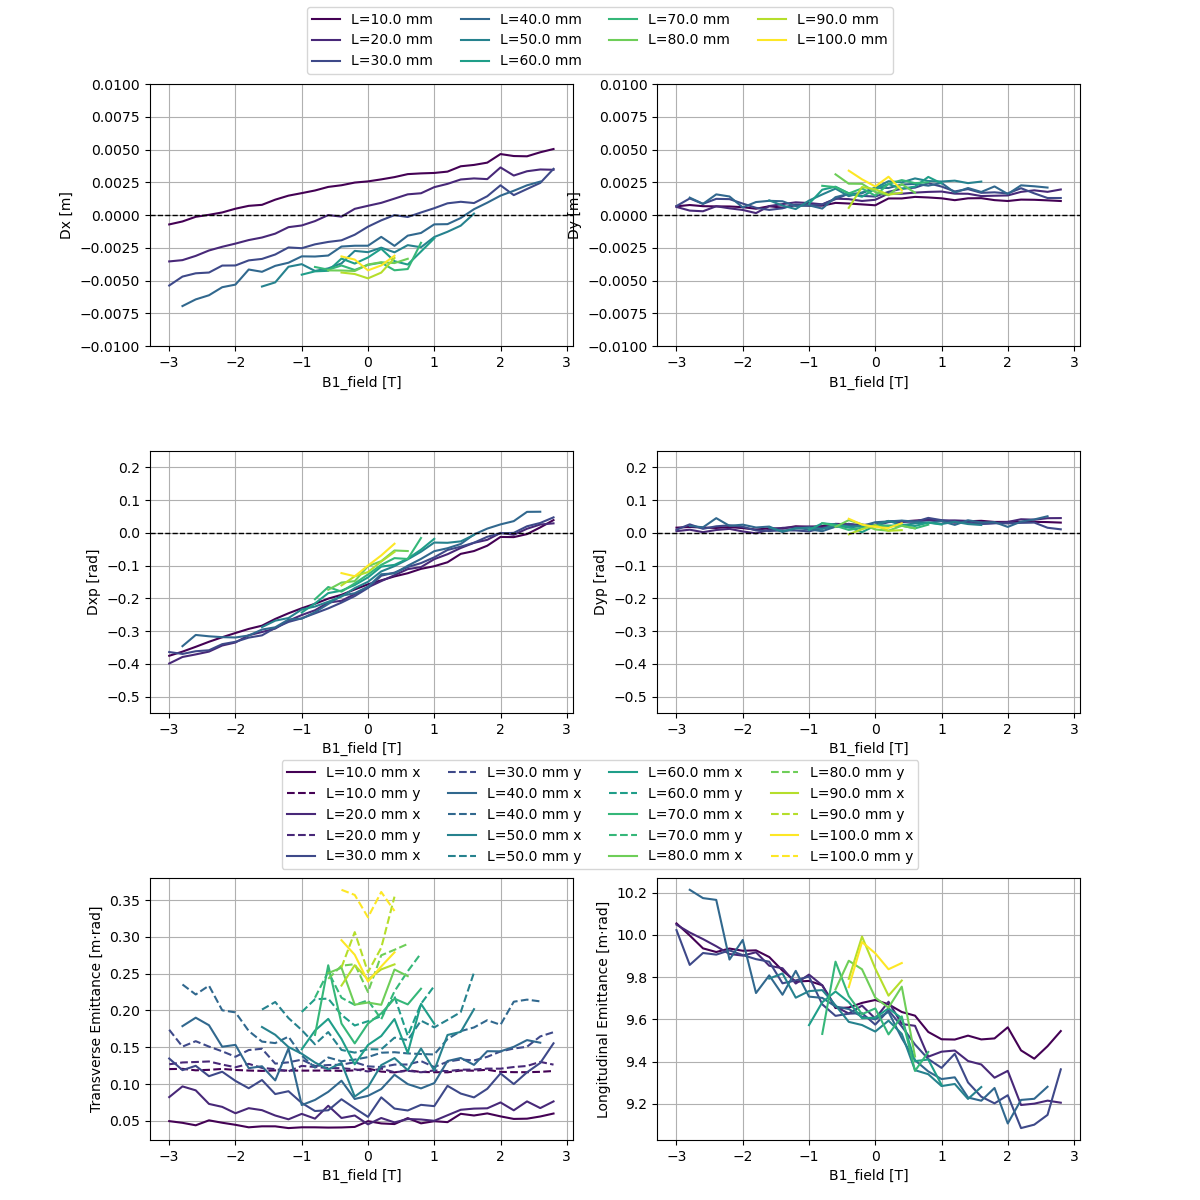

In [ ]:
colors = viridis(np.linspace(0, 1, len(sweep_results)))
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.flatten()

for j, (data_key, label) in enumerate([
    ("Dx", "Dx [m]"),
    ("Dy", "Dy [m]"),
    ("Dxp", "Dxp [rad]"),
    ("Dyp", "Dyp [rad]"),
    ("emit_xy", "Transverse Emittance [m·rad]"),
    ("emit_z", "Longitudinal Emittance [m·rad]")
]):
    ax = axs[j]

    for idx, res in enumerate(sweep_results):
        Dip1 = res["Dip1"]
        if label == "Transverse Emittance [m·rad]":
            ax.plot(Dip1, res["emit_x"], color=colors[idx], linestyle='-', label=f"L={res['B1_length']:.1f} mm x")
            ax.plot(Dip1, res["emit_y"], color=colors[idx], linestyle='--', label=f"L={res['B1_length']:.1f} mm y")
        else:
            ax.plot(Dip1, res[data_key], color=colors[idx], label=f"L={res['B1_length']:.1f} mm")
    
    
    
    if "D" in label:
        ax.axhline(0, color='k', linestyle='--', linewidth=1)

        if label == "Dxp [rad]" or label == "Dyp [rad]":

            ax.set_ylim(-0.55, 0.25)
        elif label == "Dx [m]" or label == "Dy [m]":
            ax.set_ylim(-0.01, 0.01)

    ax.set_xlabel("B1_field [T]")
    ax.set_ylabel(label)
    ax.grid(True)

# --- Create first legend for axs[0] (top center)
handles0, labels0 = axs[0].get_legend_handles_labels()
fig.legend(handles0, labels0, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.0), fontsize=10)

# --- Create second legend for axs[5] (center gap between rows)
handles5, labels5 = axs[4].get_legend_handles_labels()
fig.legend(handles5, labels5, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.27), fontsize=10)

# --- Adjust general subplot layout
fig.subplots_adjust(hspace=0.4, top=0.93, bottom=0.1)

# --- Push last two plots down slightly
for ax in axs[4:]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.05, pos.width, pos.height])  # move down 5%

plt.savefig("B1Larmor.png")
plt.show()


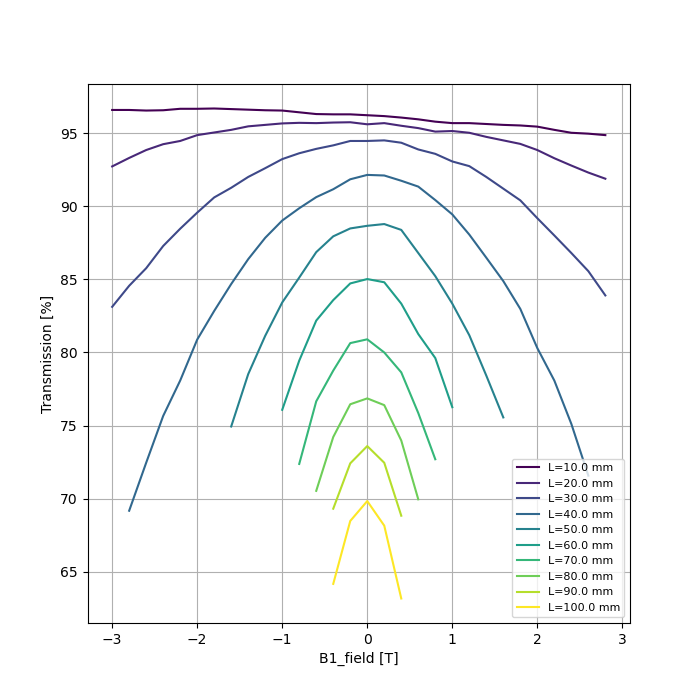

In [ ]:
colors = viridis(np.linspace(0, 1, len(results)))

plt.figure(figsize=(7, 7))

for idx, res in enumerate(sweep_results):
    Dip1 = res["Dip1"]
    plt.plot(Dip1, res["transmission"], color=colors[idx], label=f"L={res['B1_length']:.1f} mm")
    
plt.xlabel("B1_field [T]")
plt.legend(fontsize=8)
plt.ylabel("Transmission [%]")
plt.grid(True)
plt.savefig("B1trans.png")

[[   0.         0.         0.         0.        -1.76268    0.     ]
 [   0.         0.         5.         0.        -1.86372    0.     ]
 [   0.         0.        10.         0.        -1.97029    0.     ]
 ...
 [   0.         0.      1215.         0.         0.         0.     ]
 [   0.         0.      1220.         0.         0.         0.     ]
 [   0.         0.      1225.         0.         0.         0.     ]]
dict_items([('COLORS', '100'), ('B1_field', '-6.5'), ('B1_width', '74.7401'), ('B1_height', '100.0'), ('B1_length', '140.0'), ('B1_z', '190.45584412271572'), ('B2_z', '582.4610941227157'), ('Q1_z', '851.0280441227158'), ('Drift1_z', '582.4610941227157'), ('Drift2_z', '1046.0625441227157'), ('Q1_gradient', '-43.4531'), ('Q1_length', '73.1234'), ('radius_q', '100.0'), ('B2_field', '-6.5'), ('B2_width', '74.7401'), ('B2_height', '100.0'), ('B2_length', '320.0'), ('Drift1_width', '120.1356'), ('Drift1_height', '100.0'), ('Drift1_length', '463.8105'), ('Drift2_width', '102.022')

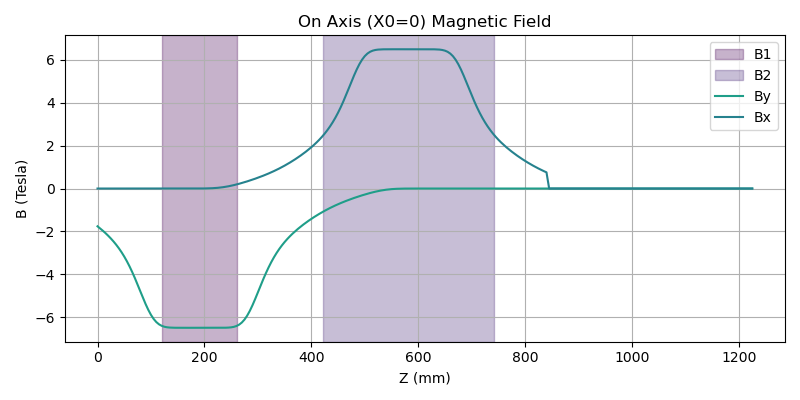

In [21]:
# Magnetic Field Evolution Across Elements
with open("field_cello.dat") as f:
        lines = f.readlines()[4:]
colors = viridis(np.linspace(0, 1, len(results)))
data = np.array([[float(x) for x in line.split()] for line in lines])
print(data)

# If the file has columns: x y z Bx By Bz
# then we can extract:
z = data[:, 2]
bx = data[:, 3]
by = data[:, 4]


# Draw shaded regions for magnets
# Read your g4bl file
with open("G4_FinalCooling_wdc_run_320.0_3.g4bl") as f:
    text = f.read()

# Extract magnets (dipoles, quads, drifts, etc.)
pattern = r"\s*([A-Za-z0-9_]+):\s*([-\d\.]+)"
entries = dict(re.findall(pattern, text))

# Convert numeric values
params = {k: float(v) for k, v in entries.items()}
print(entries.items(), params)
# Collect shading regions automatically
regions = []

color = colors
GAP = 0.1
for idx, name in enumerate(["B1", "B2"]):
    if f"{name}_z" in params:
        length = params[f"{name}_length"]
        center = params[f"{name}_z"]  # sometimes z not given (assume 0)
        z1 = center - (length / 2)
        z2 = center + (length / 2)
        regions.append((z1, z2, color[idx], name))

plt.figure(figsize=(8, 4))
for z1, z2, color, label in regions:
    if z1 is not None and z2 is not None:
        plt.axvspan(z1, z2, color=color, alpha=0.3, label=label)

plt.plot(z, by, color=colors[5], markersize=2, label="By")
plt.plot(z, bx, color=colors[4], markersize=2, label="Bx")
plt.xlabel("Z (mm)")
plt.ylabel("B (Tesla)")
plt.title("On Axis (X0=0) Magnetic Field")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Scrap

In [ ]:
for L_val in B1_length_range:
    Dx, Dy, Dxp, Dyp, Dip1, emit_x, emit_y, emit_z, transmission, x, xp, y, yp  = [], [], [], [], [], [], [], [], [], [], [], [], []

    for i, B_val in enumerate(tqdm(B1_field_range, desc=f"L = {L_val:.1f}")):
        if os.path.exists("field_cell.dat"):
            os.remove("field_cell.dat")

        var_names = ["N_PARTICLES", "B1_field", "B1_width", "B1_height", "B1_length",
                    "Q1_gradient", "Q1_length", "radius_q", "B2_field", "B2_width", "B2_height", "B2_length",
                    "Drift1_width", "Drift1_height", "Drift1_length", "Drift2_width", "Drift2_height", "Drift2_length", "VD_FILENAME"]
        #74.7401
        xvec = np.array([
            int(N_PARTICLES), B_val, 30.0, geom["Length_Wedge"], L_val,
            -43.4531, 73.1234, geom["Length_Wedge"], -0.0126, 167.5582, 144.8055, 53.6328,
            120.1356, geom["Length_Wedge"], 463.8105, 102.022, geom["Length_Wedge"], 316.7456,
            f"./runs/{VD_FILENAME}_{L_val:.1f}_{i}.txt"
        ])

        calcparams = {name: val for name, val in zip(var_names, xvec)}
        add_missing_params(calcparams)
        
        write_input_from_template(
            TEMPLATE_FILE,
            f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{G4BLFILE}_{L_val:.1f}_{i}.g4bl",
            calcparams
        )

        subprocess.run(["g4bl", f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{G4BLFILE}_{L_val:.1f}_{i}.g4bl"], 
                    capture_output=True, text=True, check=True)

        G4BLOUTPUT = f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{VD_FILENAME}_{L_val:.1f}_{i}.txt"
        df = read_trackfile(G4BLOUTPUT)
        
        # Skip if radii exceed Larmor-defined aperture
        mask, r_L_mm, delta_r_mm = check_dipole_clearance(df, B_val, L_val, calcparams["B1_width"]/2)
        
        # If less than 95% of particles clear the aperture, skip this configuration
        if np.mean(mask) < 0.95:
            print(f"Skipping B={B_val:.2f}T, L={L_val:.1f}mm: only {np.mean(mask)*100:.1f}% clear.")
            continue
    
        # Count surviving particles
        else:
            with open(G4BLOUTPUT) as f:
                N_out = sum(1 for line in f if not line.startswith("#") and line.strip())

            # Compute transmission (%)
            trans_percent = 100.0 * N_out / int(N_PARTICLES)
            transmission.append(trans_percent)
            
            # Compute D, D', Emittances vs. Dipole Strength
            x_params, y_params, z_emit = calc_all_params(df)

            Dip1.append(B_val)
            Dx.append(x_params[4])
            Dy.append(y_params[4])
            Dxp.append(x_params[5])
            Dyp.append(y_params[5])
            emit_x.append(x_params[0])
            emit_y.append(y_params[0])
            emit_z.append(z_emit)
    
    # store all results for this L_val
    results.append({
        "B1_length": L_val,
        "Dip1": Dip1,
        "Dx": Dx, "Dy": Dy, "Dxp": Dxp, "Dyp": Dyp, "xp": xp, "yp": yp, "x": x, "y":y,
        "emit_x": emit_x, "emit_y": emit_y, "emit_z": emit_z, "transmission": transmission
    })
    
    print(results)



In [ ]:
def calculate_Larmor_radius(df, B_val):
    """
    Compute mean Larmor radii in x and z directions for a given B field.
    Momentum in df is in MeV/c.
    B_val is in Tesla.
    Returns: (r_len_mm, r_wid_mm)
    """
    # Constants
    e = 1.602176634e-19  # C
    c = 2.99792458e8     # m/s
    
    # Convert momentum from MeV/c → kg·m/s
    mom_x = df["Px"] * 1e6 * e / c
    mom_z = df["Pz"] * 1e6 * e / c

    # Larmor radius = p / (|q| * B)
    # muon charge magnitude = e
    r_len_m = np.abs(mom_x) / (e * np.abs(B_val))  # bending in z
    r_wid_m = np.abs(mom_z) / (e * np.abs(B_val))  # bending in x

    # Return mean values in mm
    return np.mean(r_len_m) * 1e3, np.mean(r_wid_m) * 1e3

"""def calculate_Larmor_radius(df, B_val):
    muonCharge = 1.6e-19 #in C
    mom_x = df["Px"]*1e6*1.6e-19/(2.99e8)
    mom_z = df["Pz"]*1e6*1.6e-19/(2.99e8) # in kgm/s from MeV/c
    radius_length = np.abs(mom_x) /(muonCharge * np.abs(B_val)) #in m, force bending it in z
    radius_width = np.abs(mom_z) /(muonCharge * np.abs(B_val)) #in m, force bending it in x
    return (np.mean(radius_length) * 1e3), (np.mean(radius_width) * 1e3) #in mm
"""

# User's Manual
"""mom = 100 *1e6*1.6e-19/(2.99e8)
muonCharge = 1.6e-19 #in C
B_val = 3
radius = mom /(muonCharge * np.abs(B_val))
print(radius*1e3) #mm"""

In [ ]:
# Doing this for B1 and B1_length
B1_field_range = np.arange(-3.0, 3.0, 0.5)
B1_length_range = np.linspace(10, 320, 10) # in mm

# Initialize lists
results = []

for L_val in B1_length_range:

In [ ]:
# constants
_e = 1.602176634e-19      # C, elementary charge magnitude
_c = 2.99792458e8         # m/s
_GeV_to_J = 1.602176634e-10  # 1 GeV = 1.602176634e-10 J

def calculate_Larmor_radius_mean(df, B_val, momentum_unit="GeV"):
    """
    Return (r_length_mm, r_width_mm) where:
     - r_length comes from p_x (bending in z) compare to B1_length
     - r_width  comes from p_z (bending in x) compare to B1_width

    df: pandas DataFrame with 'Px' and 'Pz' in momentum_unit per c (either "GeV" or "MeV")
    B_val: scalar magnetic field in Tesla (use abs(B_val) for magnitude)
    """
    if momentum_unit == "GeV":
        conv = _GeV_to_J / _c   # GeV/c -> kg*m/s
    elif momentum_unit == "MeV":
        conv = (_GeV_to_J / 1e3) / _c   # MeV -> 1e-3 GeV -> J, then /c
    else:
        raise ValueError("momentum_unit must be 'GeV' or 'MeV'")

    # Convert to SI momentum (kg*m/s)
    p_x_SI = df["Px"].to_numpy() * conv
    p_z_SI = df["Pz"].to_numpy() * conv

    # Larmor radii (m) -> use magnitude of qe and B
    Bmag = np.abs(B_val)
    if Bmag == 0:
        # avoid divide by zero: infinite radius
        r_from_px_m = np.full_like(p_x_SI, np.inf)
        r_from_pz_m = np.full_like(p_z_SI, np.inf)
    else:
        r_from_px_m = np.abs(p_x_SI) / (_e * Bmag)   # p_x -> bend in z (length)
        r_from_pz_m = np.abs(p_z_SI) / (_e * Bmag)   # p_z -> bend in x (width)

    # return mean radii in mm
    r_length_mm = np.mean(r_from_px_m) * 1e3   # compare with B1_length (mm)
    r_width_mm  = np.mean(r_from_pz_m) * 1e3   # compare with B1_width  (mm)

    return r_length_mm, r_width_mm


In [ ]:
colors = viridis(np.linspace(0, 1, len(results)))

fig, axs = plt.subplots(5, 2, figsize=(7, 7))

"""for j, (data_key, label) in enumerate([("x", "x"), ("y", "y")]): 
    print(res[data_key+"p"])
    plt.scatter(res[data_key], res[data_key+"p"], color=colors[idx], label=f"B={res["Dip1"]:.1f} T, L={res['B1_length']:.1f} mm")
    axs[idx].scatter(res["x"], res["xp"], color=colors[idx], label=f"B={res["Dip1"]:.1f} T, L={res['B1_length']:.1f} mm")
    axs[j].set_xlabel(label + " [mm]")
    axs[j].set_ylabel(label+"'")
    axs[j].grid(True)
"""
for j, (data_key, label) in enumerate([("x", "x"),("y", "y")]):

    for idx, res in enumerate(results):
        axs[idx, j].scatter(res[data_key], res[data_key+"p"], color=colors[idx], label=f"L={res['B1_length']:.1f} mm")
            
    axs[idx, j].set_xlabel(label + " [mm]")
    axs[idx, j].set_ylabel(label+"'")
    axs[idx, j].grid(True)


        # Compute normalized momenta and get position for plotting phase space
        """xp.append(df["Px"] / df["Pz"])   # x' = Px/Pz
        yp.append(df["Py"] / df["Pz"])   # y' = Py/Pz
        x.append(df["x"])
        y.append(df["y"])"""

In [ ]:
# Choose colors for each B1_length
colors = viridis(np.linspace(0, 1, len(results)))

fig, axs = plt.subplots(3, 2, figsize=(10, 10))
axs = axs.flatten()

for j, (data_key, label) in enumerate([
    ("Dx", "Dx [m]"),
    ("Dy", "Dy [m]"),
    ("Dxp", "Dxp [rad]"),
    ("Dyp", "Dyp [rad]"),
    ("emit_xy", "Transverse Emittance [m·rad]"),
    ("emit_z", "emit_z [m·rad]")
]):
    ax = axs[j]

    for idx, res in enumerate(results):
        Dip1 = res["Dip1"]
        if label == "Transverse Emittance [m·rad]":
            ax.plot(Dip1, res["emit_x"], color=colors[idx], linestyle='-', label=f"L={res['B1_length']:.1f} mm emit_x")
            ax.plot(Dip1, res["emit_y"], color=colors[idx], linestyle='--', label=f"L={res['B1_length']:.1f} mm emit_y")
        else:
            ax.plot(Dip1, res[data_key], color=colors[idx], label=f"L={res['B1_length']:.1f} mm")

    if "D" in label:
        ax.axhline(0, color='k', linestyle='--', linewidth=1)

    ax.set_xlabel("B1_field [T]")
    ax.set_ylabel(label)
    ax.grid(True)

# Add legends to appropriate plots
axs[0].legend(fontsize=8)
axs[4].legend(fontsize=8)

fig.tight_layout()
plt.show()


In [ ]:
opt_bounds = np.arange(-8.0, 8.0, 0.05) # for B1, normal superconducting magnets
Dx = []
Dy = []
Dxp = []
Dyp = []
Dip1 = []
emit_z = []
emit_x = []
emit_y = []

for i, B_val in tqdm(enumerate(opt_bounds)):
        if os.path.exists("field_cell.dat"): 
                os.remove("field_cell.dat")
        var_names = ["N_PARTICLES", "B1_field", "B1_width", "B1_height", "B1_length",
        "Q1_gradient", "Q1_length", "radius_q", "B2_field", "B2_width", "B2_height", "B2_length",
        "Drift1_width", "Drift1_height", "Drift1_length", "Drift2_width", "Drift2_height", "Drift2_length", "VD_FILENAME"]
        xvec = np.array([int(N_PARTICLES), B_val, 74.7401, geom["Length_Wedge"], 177.7, -43.4531, 73.1234, geom["Length_Wedge"], -0.0126, 167.5582, 
                        144.8055, 53.6328, 120.1356, geom["Length_Wedge"], 463.8105, 102.022, geom["Length_Wedge"], 316.7456, f"./runs/{VD_FILENAME}_{i}.txt"])
        calcparams = {name: val for name, val in zip(var_names, xvec)}
        
        add_missing_params(calcparams)
        write_input_from_template(TEMPLATE_FILE, f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{G4BLFILE}_{i}.g4bl", calcparams)
        
        result = subprocess.run(["g4bl", f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{G4BLFILE}_{i}.g4bl"], capture_output=True, text=True, check=True)
        
        G4BLOUTPUT =f"/home/incik/Cooling_4D/AchromatOneByOne/runs/{VD_FILENAME}_{i}.txt"
        df = read_trackfile(G4BLOUTPUT)
        
        x_params, y_params, z_emit = calc_all_params(df)
        
        Dip1.append(B_val)
        Dx.append(x_params[4])
        Dy.append(y_params[4])
        Dxp.append(x_params[5])
        Dyp.append(y_params[5])
        emit_x.append(x_params[0])
        emit_y.append(y_params[0])
        emit_z.append(z_emit)


In [ ]:
# Get 6 evenly spaced colors from the viridis colormap
show_col = viridis(np.linspace(0, 1, 7))

# Create figure and axes
fig, axs = plt.subplots(3, 2, figsize=(10, 10))
axs = axs.flatten()

# Define plot data and labels
plots = [
    (Dx, "Dx [m]"),
    (Dy, "Dy [m]"),
    (Dxp, "Dxp [rad]"),
    (Dyp, "Dyp [rad]"),
    ("emit_xy", "Transverse Emittance [m·rad]"),
    (emit_z, "emit_z [m·rad]"),
]

for i, (data, label) in enumerate(plots):
    ax = axs[i]
    
    if label == "Transverse Emittance [m·rad]":
        # Special case: emit_x and emit_y in same plot
        ax.plot(Dip1, emit_x, color=show_col[i], label="emit_x", linewidth=2)
        ax.plot(Dip1, emit_y, color=show_col[(i + 1) % 6], label="emit_y", linewidth=2)
        ax.legend()
    else:
        ax.plot(Dip1, data, color=show_col[i], linewidth=2)
        # Add horizontal dashed line at y=0 for Dx, Dy, Dxp, Dyp
        if "D" in label:
            ax.axhline(0, color='k', linestyle='--', linewidth=1)

    ax.set_xlabel("Dip1 [arb. units]")
    ax.set_ylabel(label)
    ax.grid(True)

# fig.suptitle("Beam Parameters vs Dipole Field", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()